# Quickstart: NOAA HRRR forecast 48 hour - dynamical.org Zarr
A brief introduction to the NOAA HRRR forecast 48 hour dataset transformed into an analysis-ready, cloud-optimized format by dynamical.org.

Dataset documentation: https://dynamical.org/catalog/noaa-hrrr-forecast-48-hour/

In [ ]:
# If running locally, follow README.md for simple dependency installation.
# If using Google Colab, run this cell and then restart the notebook.
%pip install "xarray[complete]>=2025.1.2" "zarr>=3.0.8" requests aiohttp rioxarray pyproj
# rioxarray and pyproj are used here for working with map projections

In [1]:
import xarray as xr

ds = xr.open_zarr("https://data.dynamical.org/noaa/hrrr/forecast-48-hour/latest.zarr?email=optional@email.com", chunks=None)
ds

<xarray.Dataset> Size: 79TB
Dimensions:                                     (init_time: 10535,
                                                 lead_time: 49, y: 1059, x: 1799)
Coordinates:
    expected_forecast_length                    (init_time) timedelta64[ns] 84kB ...
    ingested_forecast_length                    (init_time) timedelta64[ns] 84kB ...
  * init_time                                   (init_time) datetime64[ns] 84kB ...
    latitude                                    (y, x) float32 8MB ...
  * lead_time                                   (lead_time) timedelta64[ns] 392B ...
    longitude                                   (y, x) float32 8MB ...
    spatial_ref                                 int64 8B ...
    valid_time                                  (init_time, lead_time) datetime64[ns] 4MB ...
  * x                                           (x) float64 14kB -2.698e+06 ....
  * y                                           (y) float64 8kB 1.587e+06 ......
Data variables: (12/20)
    categorical_freezing_rain_surface           (init_time, lead_time, y, x) float32 4TB ...
    categorical_ice_pellets_surface             (init_time, lead_time, y, x) float32 4TB ...
    categorical_rain_surface                    (init_time, lead_time, y, x) float32 4TB ...
    categorical_snow_surface                    (init_time, lead_time, y, x) float32 4TB ...
    composite_reflectivity                      (init_time, lead_time, y, x) float32 4TB ...
    downward_long_wave_radiation_flux_surface   (init_time, lead_time, y, x) float32 4TB ...
    ...                                          ...
    temperature_2m                              (init_time, lead_time, y, x) float32 4TB ...
    total_cloud_cover_atmosphere                (init_time, lead_time, y, x) float32 4TB ...
    wind_u_10m                                  (init_time, lead_time, y, x) float32 4TB ...
    wind_u_80m                                  (init_time, lead_time, y, x) float32 4TB ...
    wind_v_10m                                  (init_time, lead_time, y, x) float32 4TB ...
    wind_v_80m                                  (init_time, lead_time, y, x) float32 4TB ...
Attributes:
    dataset_id:           noaa-hrrr-forecast-48-hour
    dataset_version:      0.1.0
    name:                 NOAA HRRR forecast, 48 hour
    description:          Weather forecasts from the High Resolution Rapid Re...
    attribution:          NOAA NWS NCEP HRRR data processed by dynamical.org ...
    spatial_domain:       Continental United States
    spatial_resolution:   3km
    time_domain:          Forecasts initialized 2018-07-13 12:00:00 UTC to Pr...
    time_resolution:      Forecasts initialized every 6 hours.
    forecast_domain:      Forecast lead time 0-48 hours ahead
    forecast_resolution:  Hourly

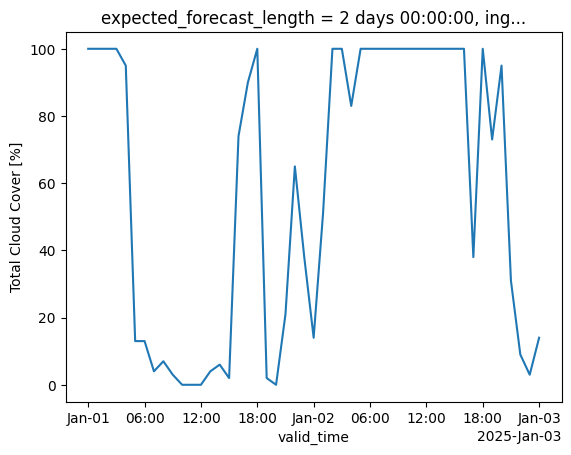

In [2]:
# Plot a forecast of cloud cover at a specific location
ds["total_cloud_cover_atmosphere"].sel(init_time="2025-01-01T00", x=0, y=0, method="nearest").plot(x="valid_time")

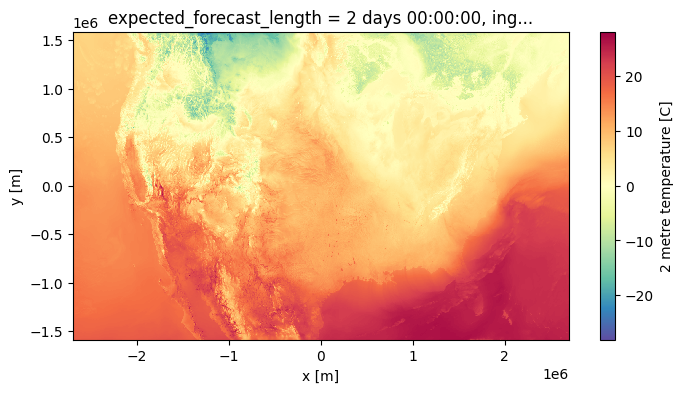

In [3]:
# Plot 2 meter air temperature from a specific model run (init_time) and forecast lead time
(
    ds["temperature_2m"]
    .sel(init_time="2020-04-01T00", lead_time="6h")
    .plot(figsize=(8, 4), cmap="Spectral_r")
)

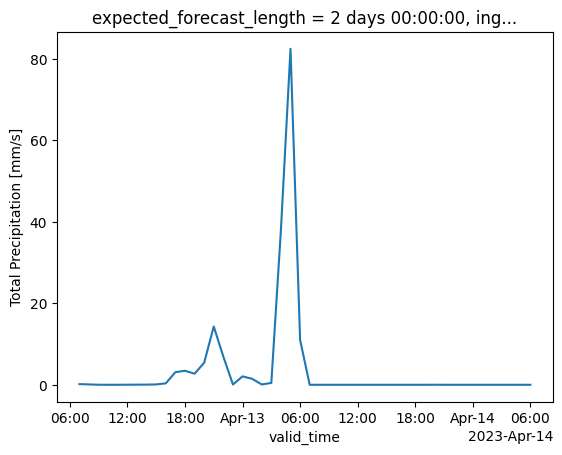

In [4]:
# HRRR data is distributed in a projected coordinate system and 
# we include its details in the dataset metadata (e.g. ds.rio.crs, ds.rio.transform()).

# Use pyproj to transform the longitude and latitude of Fort Lauderdale, FL into dataset x, y coordinates
import rioxarray  # for .rio accessor
from pyproj import Transformer

lon_lat_to_ds = Transformer.from_crs("EPSG:4326", ds.rio.crs, always_xy=True)
x, y = lon_lat_to_ds.transform(-80.1, 26.1)

ds["precipitation_surface"].sel(init_time="2023-04-12T06", x=x, y=y, method="nearest").plot(x="valid_time")

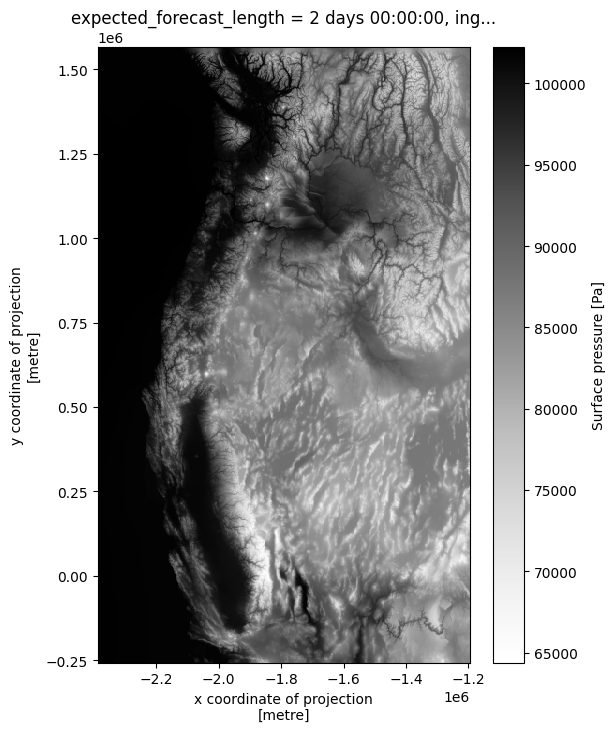

In [5]:
# Select a geographic area using (west, south, east, north) longitude/latitude coordinates
(
    ds["pressure_surface"]
    .rio.clip_box(-124, 35, -114, 50, crs="EPSG:4326")
    .sel(init_time="2025-08-01T00", lead_time="12h")
    .plot(figsize=(6, 8), cmap="Greys")
)

# To aggregate data over one or more geometries (e.g. country borders, watersheds, custom polygons),
# see rioxarray's. ds.rio.clip() and the xvec library's zonal statistics functions.

<xarray.DataArray 'precipitation_surface' (lead_time: 49, point: 414)> Size: 81kB
array([[ 0.       ,  0.       ,  0.       , ...,  0.       ,  0.       ,
         0.       ],
       [ 0.       ,  0.       ,  0.       , ...,  0.       ,  0.       ,
         0.       ],
       [ 0.       ,  0.       ,  0.       , ...,  0.       ,  0.       ,
         0.       ],
       ...,
       [12.956957 ,  7.9305887,  4.303516 , ...,  0.       ,  0.       ,
         0.       ],
       [12.957097 ,  7.935677 ,  4.3282933, ...,  0.       ,  0.       ,
         0.       ],
       [12.957097 ,  7.935677 ,  4.3363013, ...,  0.       ,  0.       ,
         0.       ]], shape=(49, 414), dtype=float32)
Coordinates:
    expected_forecast_length  timedelta64[ns] 8B ...
    ingested_forecast_length  timedelta64[ns] 8B ...
    init_time                 datetime64[ns] 8B 2025-09-26
    latitude                  (point) float32 2kB 48.61 48.35 ... 45.95 45.69
  * lead_time                 (lead_time) timedelta64[ns] 392B 00:00:00 ... 2...
    longitude                 (point) float32 2kB -125.8 -125.7 ... -115.8
    valid_time                (lead_time) datetime64[ns] 392B ...
    spatial_ref               int64 8B 0
  * point                     (point) object 3kB MultiIndex
  * x                         (point) float64 3kB -2.084e+06 ... -1.424e+06
  * y                         (point) float64 3kB 1.453e+06 ... 9.432e+05

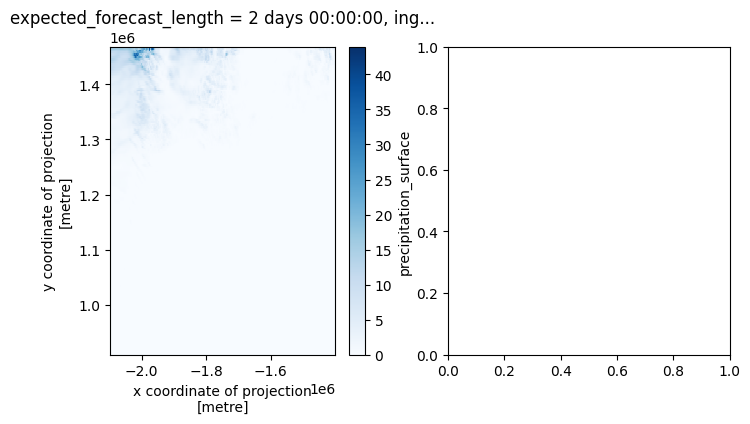

In [15]:
wa_precip_accum = (
    ds["precipitation_surface"]
    .rio.clip_box(-124.5, 45.3, -116.5, 49, crs="EPSG:4326") # Roughly Washington state
    .sel(init_time="2025-09-26T00")
    .cumsum(dim="lead_time")
)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(ncols=2, figsize=(8, 4))

wa_precip_accum.isel(lead_time=-1).plot(cmap="Blues", ax=ax[0])
wa_precip_accum.coarsen(x=10, y=10, boundary="trim").mean().stack(point=("x", "y")) # .plot.line(x="lead_time", hue="point", ax=ax[1])